In [1]:
import os, yaml, sys
import numpy as np
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt

ENV = os.getenv("MY_ENV", "dev")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
from general_utils.utils import load_img_natraster, print_wise,  get_triu_perms
from general_utils.II import compare_similarity_metrics, dyn_compare_similarity_metrics


In [25]:
from dataclasses import dataclass, field

@dataclass
class Cfg:
    monkey_name = 'three0'
    date = '250313'
    new_fs: int = 100 # Hz
    channels_idx = np.arange(20)
    brain_area = "AIT"
    new_fs = 100
    RDM_metric_A = "euclidean"
    RDM_metric_B = "magnitude_diff"
    metrics = ['euclidean', 'cosine_cnt', 'correlation', "magnitude_diff"]
    k: int = 1
cfg = Cfg()


In [3]:
ba_raster = load_img_natraster(paths, cfg.monkey_name, cfg.date, brain_area=cfg.brain_area, new_fs=cfg.new_fs)

In [21]:
metrics_perms = get_triu_perms(cfg.metrics) # "mahalanobis",

In [5]:

def dyn_compare_similarity_metrics(paths, rank, metrics_tuple, monkey_name, date, brain_area, new_fs):
    save_name_A2B = f"{paths['livingstone_lab']}/tiziano/results/metric_comparison_{metrics_tuple[0]}-{metrics_tuple[1]}_{monkey_name}_{date}_{brain_area}_{new_fs}Hz.npz"
    save_name_B2A = f"{paths['livingstone_lab']}/tiziano/results/metric_comparison_{metrics_tuple[1]}-{metrics_tuple[0]}_{monkey_name}_{date}_{brain_area}_{new_fs}Hz.npz"
    if os.path.exists(save_name_A2B) and os.path.exists(save_name_B2A):
        print_wise(f"model already exists at {save_name_A2B}", rank=rank)
    else:
        A2B_list = []
        B2A_list = []
        for idx, resp_t in enumerate(ba_raster):
            _, A2B, B2A =compare_similarity_metrics(resp_t, cfg.RDM_metric_A, cfg.RDM_metric_B, cfg.k)
            A2B_list.append(A2B)
            B2A_list.append(B2A)
        # end for idx, resp_t in enumerate(ba_raster):
        np.savez_compressed(save_name_A2B, np.stack(A2B_list))
        np.savez_compressed(save_name_B2A, np.stack(B2A_list))
    # end if os.path.exists(save_name_A2B) and os.path.exists(save_name_B2A):
# EOF

In [ ]:
# np.savez_compressed()
print(f"{paths['livingstone_lab']}/tiziano/results/metric_comparison_{cfg.RDM_metric_A}-{cfg.RDM_metric_B}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.new_fs}Hz.npz")

/Users/tizianocausin/livingstone_lab_local/tiziano/results/metric_comparison_cosine_cnt2cosine_three0_250313_AIT_100Hz.npz


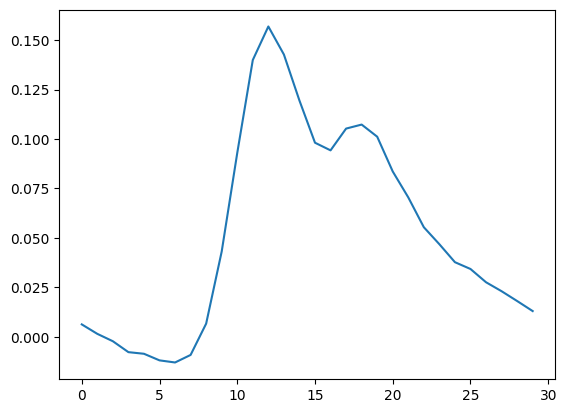

In [6]:
plt.plot(np.mean(ba_raster.get_array(), axis=(0,2)))

In [ ]:
dyn_compare_similarity_metrics(paths, 0, (cfg.RDM_metric_A, cfg.RDM_metric_B), ba_raster, cfg.k, cfg.monkey_name, cfg.date, cfg.brain_area, cfg.new_fs)


16:02:00 - rank 0 comparison saved at /Users/tizianocausin/livingstone_lab_local/tiziano/results/metric_comparison_k1_euclidean-magnitude_diff_three0_250313_AIT_100Hz.npz


In [16]:
A2B_list = np.load(f"/Users/tizianocausin/livingstone_lab_local/tiziano/results/metric_comparison_k1_{cfg.RDM_metric_A}-{cfg.RDM_metric_B}_three0_250313_AIT_100Hz.npz")["arr_0"]
B2A_list = np.load(f"/Users/tizianocausin/livingstone_lab_local/tiziano/results/metric_comparison_k1_{cfg.RDM_metric_B}-{cfg.RDM_metric_A}_three0_250313_AIT_100Hz.npz")["arr_0"]

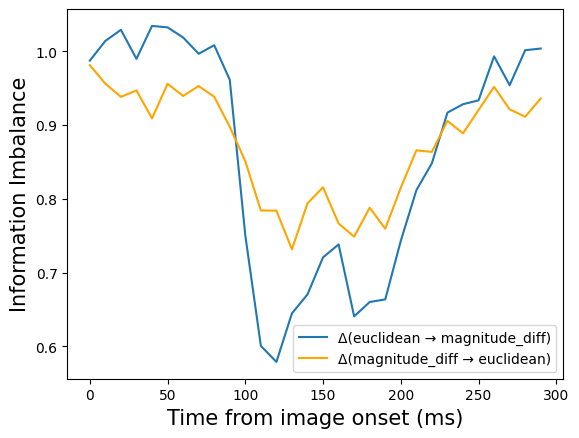

In [17]:
plt.plot(np.arange(0, len(A2B_list))*1000//cfg.new_fs,A2B_list, label=f"{chr(916)}({cfg.RDM_metric_A} {chr(8594)} {cfg.RDM_metric_B})")
plt.plot(np.arange(len(A2B_list))*1000//cfg.new_fs, B2A_list, label=f"{chr(916)}({cfg.RDM_metric_B} {chr(8594)} {cfg.RDM_metric_A})", color="orange")
plt.ylabel("Information Imbalance", fontsize=15)
plt.xlabel("Time from image onset (ms)", fontsize=15)
plt.legend()

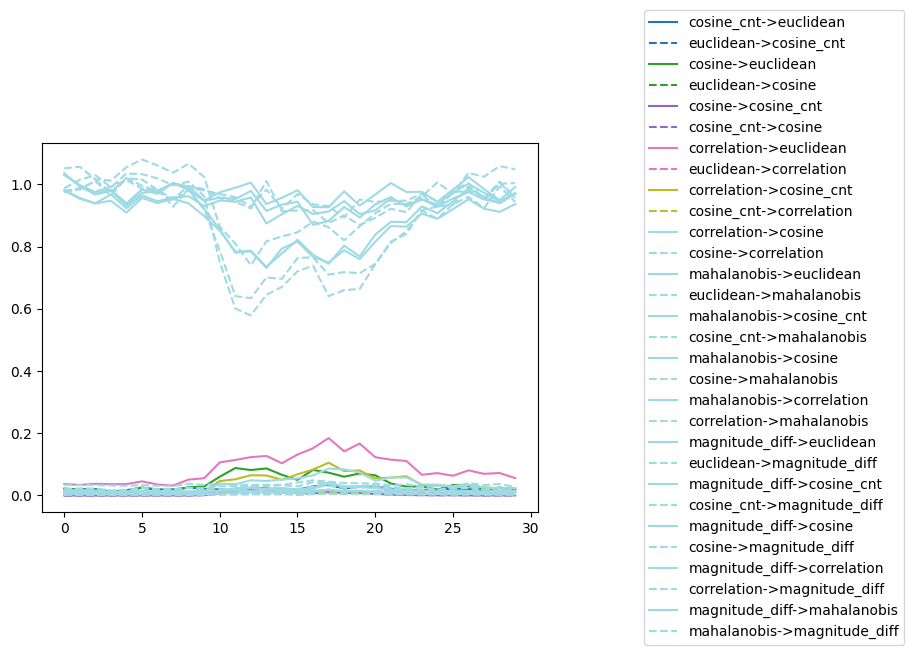

In [23]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors

# 1. Define your colormap and normalization based on the number of metrics
cmap = cm.tab20
norm = colors.Normalize(vmin=0, vmax=len(cfg.metrics) - 1)
for i, metrics_tuple in enumerate(metrics_perms):
    save_name_A2B = f"{paths['livingstone_lab']}/tiziano/results/metric_comparison_k{cfg.k}_{metrics_tuple[0]}-{metrics_tuple[1]}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.new_fs}Hz.npz"
    save_name_B2A = f"{paths['livingstone_lab']}/tiziano/results/metric_comparison_k{cfg.k}_{metrics_tuple[1]}-{metrics_tuple[0]}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.new_fs}Hz.npz"
    
    A2B = np.load(save_name_A2B)["arr_0"]
    B2A = np.load(save_name_B2A)["arr_0"]
    
    # 2. Assign color based on the loop index
    line_color = cmap(norm(i))
    
    plt.plot(A2B, color=line_color, label=f"{metrics_tuple[0]}->{metrics_tuple[1]}")
    # Using a dashed line or different alpha for the reverse to distinguish them
    plt.plot(B2A, color=line_color, linestyle='--', label=f"{metrics_tuple[1]}->{metrics_tuple[0]}")

# Optional: keep the legend if you still need specific labels
plt.legend(loc="center left", bbox_to_anchor=(1.2, 0.5))

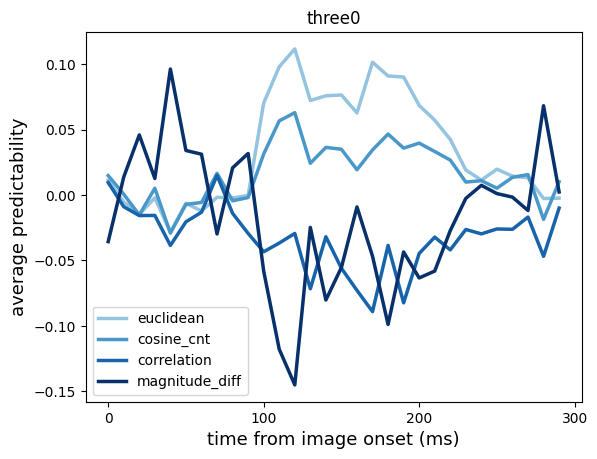

In [26]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
from general_utils.plots import truncate_colormap
# 1. Define your colormap and normalization based on the number of metrics
cmap = truncate_colormap(cm.Blues, .4, 1)
norm = colors.Normalize(vmin=0, vmax=len(cfg.metrics) - 1)
for i, target_metric in enumerate(cfg.metrics):
    tot_pred_diff = []
    for comparing_metric in cfg.metrics:
        if comparing_metric == target_metric:
                continue
        save_name_A2B = f"{paths['livingstone_lab']}/tiziano/results/metric_comparison_k{cfg.k}_{target_metric}-{comparing_metric}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.new_fs}Hz.npz"
        save_name_B2A = f"{paths['livingstone_lab']}/tiziano/results/metric_comparison_k{cfg.k}_{comparing_metric}-{target_metric}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.new_fs}Hz.npz"
        A2B = np.load(save_name_A2B)["arr_0"]
        B2A = np.load(save_name_B2A)["arr_0"]
        pred_diff = B2A - A2B
        tot_pred_diff.append(pred_diff)
    avg_pred_diff = np.sum(tot_pred_diff, axis=0)/(len(cfg.metrics)-1)
    line_color = cmap(norm(i))
    plt.plot(avg_pred_diff, color=line_color, label=target_metric, linewidth=2.5)
plt.ylabel("average predictability", fontsize=13)
plt.xlabel("time from image onset (ms)", fontsize=13)
# Create the positions (locations on the x-axis)
ticks_loc = np.arange(0, len(avg_pred_diff)+1, 10)
ticks_labels = [int(xt * 1000 / cfg.new_fs) for xt in ticks_loc]
plt.xticks(ticks_loc, ticks_labels)
plt.title(cfg.monkey_name)
#     # 2. Assign color based on the loop index
#     line_color = cmap(norm(i))
plt.legend()
#     plt.plot(A2B, color=line_color, label=f"{metrics_tuple[0]}->{metrics_tuple[1]}")
#     # Using a dashed line or different alpha for the reverse to distinguish them
#     plt.plot(B2A, color=line_color, linestyle='--', label=f"{metrics_tuple[1]}->{metrics_tuple[0]}")

# # Optional: keep the legend if you still need specific labels
# plt.legend(loc="center left", bbox_to_anchor=(1.2, 0.5))